In [3]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

material

In [4]:
# characteristic lifetime distribution
dτ  = 5e-4
fine_τ_grid = np.arange(dτ, 5, dτ)

gauss_I_τ = np.vstack(np.array([0.40,  0.50, 0.10]))
gauss_τ = np.vstack(np.array([0.125, 0.45, 3.0]))
gauss_σ_τ = np.vstack(np.array([0.0015, 0.05, 0.3]))   # width in τ (ns)

#gauss_I_τ = np.vstack(np.array([0.25,  0.2, 0.25, .3]))
#gauss_τ = np.vstack(np.array([0.14, 0.185, 0.3, 1]))
#gauss_σ_τ = gauss_τ*0.1


true_τ_distribution = (gauss_I_τ / np.sqrt(2*np.pi*gauss_σ_τ**2) * np.exp(-(gauss_τ - fine_τ_grid) ** 2 / (2*gauss_σ_τ**2))).sum(axis=0)

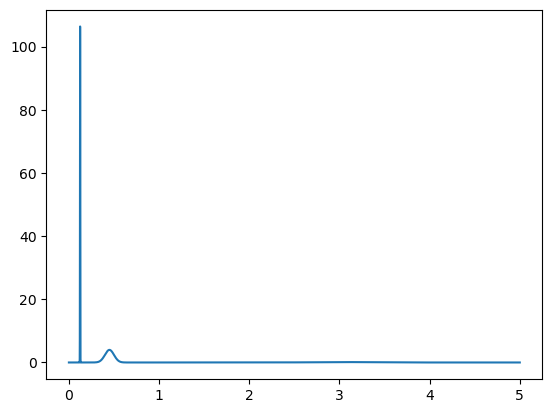

In [5]:
plt.plot(fine_τ_grid, true_τ_distribution)

In [6]:
irf_sigma = np.array([0.250/(2*np.sqrt(2*np.log(2)))])
IRF = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

In [7]:
lt_model = LifetimeModel("simulation", lifetimes=fine_τ_grid, intensities=true_τ_distribution)
time_step = 5e-3 # 5 picosecond
time = np.arange(-2, 40, time_step)
bg_frac = 0.1

expected_background = bg_frac/(time[-1]-time[0]) * np.ones_like(time)
analytical_spectrum = generate_analytical_lt_spectrum(time, lt_model, IRF, bg_frac)
random_spectrum = generate_random_lt_spectrum(time, lt_model, IRF, bg_frac, int(1e7))

In [8]:
# resolution function using response to impulse
impulse = np.zeros_like(time)
impulse[np.where(time>0)[0][0]] = 1/(time[1] - time[0])

res_fun = IRF.convolve(impulse,time)

(-1.0, 20.0)

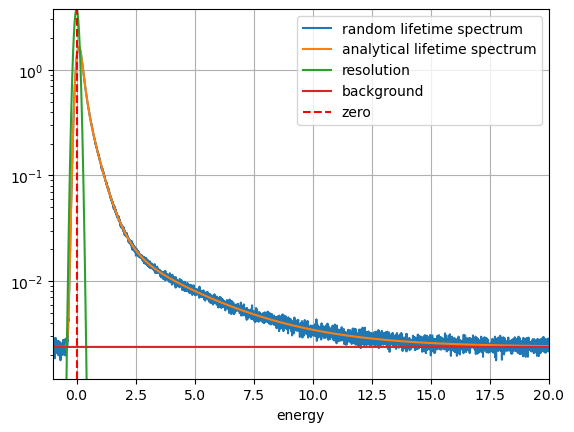

In [9]:
random_normalizer = random_spectrum.lifetime.integrate('energy').item()
(random_spectrum.lifetime/random_normalizer).plot(label='random lifetime spectrum', yscale='log')
(analytical_spectrum.lifetime).plot(label='analytical lifetime spectrum', yscale='log')

plt.plot(time, res_fun, label='resolution')
plt.plot(time, expected_background, label='background')
plt.axvline(0, color='red', label='zero', ls='--')
plt.legend()
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])
plt.grid()
plt.xlim([-1, 20])

# Inversion

In [10]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization
from pyPAS.optimizer.lifetime.inversion.maximum_entropy import MaximalEntropyInversion

In [11]:
dτ = 2.5e-2
τ_grid = np.arange(dτ, 5, dτ)

dt = 5e-3
time_grid = np.arange(-2, 40, dt)

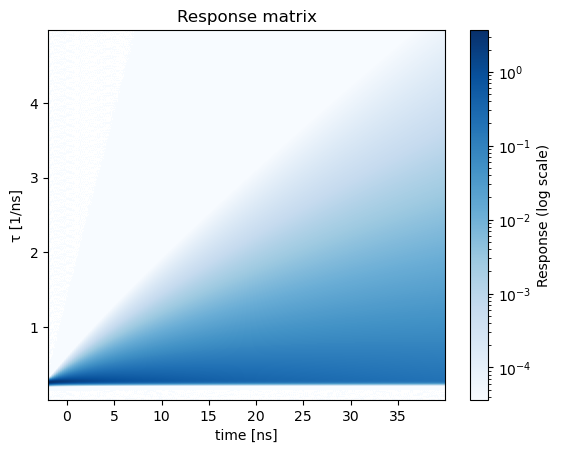

In [12]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[time.min(), time.max(),
                   τ_grid.min(), τ_grid.max()],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.xlabel('time [ns]')
plt.ylabel('τ [1/ns]')
plt.show()

In [ ]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, error=True, background_value=random_spectrum.lifetime.counts[-1000:].mean())

In [ ]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

In [ ]:
q[40:].sum()/q.sum()

In [ ]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.yscale("log")
plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()

In [ ]:
tikhonov_result_model = LifetimeModel('', τ_grid, q/np.trapz(q,τ_grid))
tikhonov_lifetime = generate_analytical_lt_spectrum(time,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=0)
tikhonov_lifetime.lifetime.counts *= np.trapz(q, τ_grid)
tikhonov_lifetime.lifetime.counts += random_spectrum.lifetime.counts[-1000:].mean()
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
(tikhonov_lifetime.lifetime/tikhonov_lifetime.lifetime.integrate('energy')).plot(yscale='log', label='tikhonov')

plt.grid(which="both")

plt.ylim([random_spectrum.lifetime.counts[-1000:].mean()/random_spectrum.lifetime.integrate('energy'),(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).max()])
plt.legend()

MELT

In [ ]:
import numpy as np
from scipy.optimize import minimize
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate


class MaximalEntropyInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution f(τ)
    using the Maximum Entropy Method (MELT), following Bryan (1990).

    Maximizes:  Q(f, α) = α·S(f) - L(f)

        S(f) = Σ(fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ))   entropy relative to prior m (≤ 0)
        L(f) = ½·χ²                             negative log-likelihood

    f is parameterized as fᵢ = mᵢ·exp(Uᵢₜ·u) (Bryan eq. 9), restricting the
    solution to the data-visible subspace and keeping f > 0 by construction.

    Background is subtracted before normalization. Alpha and f are optimized
    jointly in log-alpha space via Powell.

    Reference: Bryan, R.K. (1990). Maximum Entropy and Bayesian Methods, 221-232.
    """

    def _entropy(self, f: np.ndarray, prior: np.ndarray) -> float:
        """
        S(f|m) = Σ(fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ)) ≤ 0.
        Zero only when f == m. Penalizes deviation from the prior.
        """
        f = np.clip(f, 1e-30, None)
        return np.sum(f - prior - f * np.log(f / prior))

    def _likelihood(self,
                    f: np.ndarray,
                    U: np.ndarray,
                    V: np.ndarray,
                    sigma: np.ndarray,
                    Ut: np.ndarray,
                    data: np.ndarray,
                    data_err: np.ndarray) -> float:
        """
        L(f) = ½·χ² = ½ Σ (F_k - D_k)² / σ_k²

        Forward model via truncated SVD: F = V @ diag(σ) @ Uᵀ @ f.
        data and data_err are precomputed in invert — not recomputed here.

        Parameters
        ----------
        f        : current lifetime distribution, shape (N_tau,).
        U, V, sigma, Ut : truncated SVD components (Bryan convention).
        data     : background-subtracted normalized spectrum, shape (N_time,).
        data_err : per-channel Poisson uncertainty on data, shape (N_time,).
        """
        F = V @ (sigma * (Ut @ f))
        return 0.5 * np.sum((data - F) ** 2 / data_err ** 2)

    def _Q(self, f, alpha, prior, U, V, sigma, Ut, data, data_err) -> float:
        """Q = α·S(f) - L(f), to be maximized over f and alpha."""
        return (alpha * self._entropy(f, prior)
                - self._likelihood(f, U, V, sigma, Ut, data, data_err))

    def _f_from_u(self, u: np.ndarray, prior: np.ndarray, U: np.ndarray) -> np.ndarray:
        """
        Bryan eq. (9): fᵢ = mᵢ · exp(Uᵢₜ · u).
        Keeps f > 0 by construction and restricts solution to the
        data-visible subspace, reducing optimization from N_tau to s variables.
        """
        return prior * np.exp(U @ u)

    def _optimize_f(self, alpha, prior, U, V, sigma, Ut, data, data_err, u0):
        """
        Maximize Q over u at fixed alpha via L-BFGS-B.
        Operates in the s-dimensional subspace (s << N_tau).

        Parameters
        ----------
        alpha          : fixed regularization parameter.
        prior          : prior model, shape (N_tau,).
        U, V, sigma, Ut: truncated SVD components.
        data, data_err : precomputed normalized spectrum and uncertainties.
        u0             : warm-start vector, shape (s,).

        Returns
        -------
        f_hat : optimal distribution at this alpha, shape (N_tau,).
        u_opt : optimal subspace vector, shape (s,).
        """
        def neg_Q(u):
            return -self._Q(self._f_from_u(u, prior, U),
                            alpha, prior, U, V, sigma, Ut, data, data_err)

        result = minimize(neg_Q, u0, method='L-BFGS-B')
        return self._f_from_u(result.x, prior, U), result.x

    def _optimize(self, prior, U, V, sigma, Ut, data, data_err,
                  initial_alpha, alpha_bounds, ftol, maxiter):
        """
        Jointly optimize f and alpha via Powell in log-alpha space.
        At each Powell step, f is optimized at the proposed alpha via L-BFGS-B.
        u is warm-started between Powell steps for efficiency.

        Parameters
        ----------
        prior          : prior model, shape (N_tau,).
        U, V, sigma, Ut: truncated SVD components (Bryan convention).
        data, data_err : precomputed normalized spectrum and uncertainties.
        initial_alpha  : starting point for alpha search.
        alpha_bounds   : (min, max) search range for alpha.
        ftol           : Powell convergence tolerance.
        maxiter        : max Powell iterations.

        Returns
        -------
        alpha_opt : optimal regularization parameter.
        f_hat     : optimal lifetime distribution, shape (N_tau,).
        """
        u = np.zeros(len(sigma))

        def objective(log_alpha):
            nonlocal u
            alpha = np.exp(log_alpha)
            f_hat, u = self._optimize_f(alpha, prior, U, V, sigma, Ut, data, data_err, u)
            return -self._Q(f_hat, alpha, prior, U, V, sigma, Ut, data, data_err)

        result = minimize(
            objective,
            x0=np.log(initial_alpha),
            method='Powell',
            bounds=[(np.log(alpha_bounds[0]), np.log(alpha_bounds[1]))],
            options={"ftol": ftol, "maxiter": maxiter}
        )

        alpha_opt = np.exp(result.x.item())
        f_hat, _ = self._optimize_f(alpha_opt, prior, U, V, sigma, Ut, data, data_err, u)
        return alpha_opt, f_hat

    def _compute_covariance(self, f_hat, U, V, sigma, Ut, data_err, alpha):

        # Step 1: Ks = Ut @ diag{f} @ U  (s×s metric in singular space)
        Ks = Ut @ np.diag(f_hat) @ U
    
        # Step 2: Eigendecompose Ks = P Xi P^T  (eq. 5)
        xi, P = np.linalg.eigh(Ks)
        xi = np.maximum(xi, 0)
        sqrt_xi = np.sqrt(xi)
        # safe inverse sqrt — zero out near-singular directions
        inv_sqrt_xi = np.where(xi > 1e-10, 1.0 / np.maximum(sqrt_xi, 1e-10), 0.0)
    
        # Step 3: Ms = Sigma @ Vt @ diag{1/sigma_k^2} @ V @ Sigma
        # second derivative of L w.r.t F is diag{1/sigma_k^2} for Gaussian noise
        W = 1.0 / data_err**2
        Ms = (sigma[:, None] * V.T) * W @ (V * sigma[None, :])
    
        # Step 4: Form B = diag{sqrt_xi} @ P^T @ Ms @ P @ diag{sqrt_xi}
        # This is the matrix whose eigenvectors ARE R  (eq. 5 + surrounding text)
        B = (sqrt_xi[:, None] * P.T) @ Ms @ (P * sqrt_xi[None, :])
    
        # Step 5: Eigendecompose B -> R (eigenvectors), Lambda (eigenvalues)
        # R is NOT trivial — this is the step you were skipping
        lambdas, R = np.linalg.eigh(B)
        lambdas = np.maximum(lambdas, 0)
    
        # Step 6: Build Ys_inv = R^T @ diag{sqrt_xi} @ P^T  (eq. 6)
        Ys_inv = R.T * sqrt_xi[:, None] @ P.T   # shape (s, s)
    
        # Step 7: Recover Y from Ys_inv
        # Y = P @ diag{inv_sqrt_xi} @ R
        # because: Ys_inv @ Y = R^T diag{sqrt_xi} P^T @ P diag{inv_sqrt_xi} R
        #                     = R^T diag{sqrt_xi} diag{inv_sqrt_xi} R
        #                     = R^T R = I
        Y = P * inv_sqrt_xi[None, :] @ R        # shape (s, s)

        # Step 8: Cov(f) = diag{f} U Y diag{1/(alpha+lambda)} Y^T Ut diag{f}  (eq. 18)
        # second term of eq (18) — first term 1/alpha * diag{f} is the prior contribution
        scale = 1.0 / (alpha + lambdas)
        core = Y * scale @ Y.T                  # (s×s)
        Cov = np.diag(f_hat) @ U @ core @ Ut @ np.diag(f_hat)
    
        std = np.sqrt(np.maximum(np.diag(Cov), 0))
        return Cov, std
    
    def invert(self,
               pals: PASLifetime,
               bg_est: float = 0.0,
               noise_level: float = 1e-3,
               initial_alpha: float = 1e-3,
               alpha_bounds: tuple = (1e-10, 1e2),
               prior_model: np.ndarray = None,
               minimization_ftol: float = 1e-6,
               maxiter: int = None) -> tuple[float, np.ndarray]:
        """
        Invert a positron lifetime spectrum into a distribution f(τ).

        Parameters
        ----------
        pals              : measured lifetime spectrum with resolution function.
        bg_est            : per-channel background (counts/channel) from tail
                            estimate: np.mean(counts[time > tail_start]).
                            Subtracted before normalization. Default 0.
        t0_shift          : time-axis shift in ns from a reference measurement.
                            Applied before building the response matrix. Default 0.
        noise_level       : SVD truncation threshold relative to the largest
                            singular value. Controls rank s. Default 1e-3.
        initial_alpha     : starting alpha for the optimizer. Default 1e-3.
        alpha_bounds      : (min, max) search range for alpha. Default (1e-10, 1e2).
        prior_model       : prior over tau grid. Default flat (uniform).
        minimization_ftol : Powell convergence tolerance. Default 1e-6.
        maxiter           : max Powell iterations. Default 10 * n_tau.

        Returns
        -------
        alpha_opt : optimal regularization parameter.
        f_hat     : lifetime distribution over characteristic_time_grid.
        """
        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if maxiter is None:
            maxiter = 10 * n_tau
        if prior_model is None:
            prior_model = np.ones(n_tau) / n_tau

        # Background subtraction then normalization — bg excluded from norm
        counts = pals.lifetime.counts
        net_counts = counts - bg_est
        norm = net_counts.sum()
        data = net_counts / norm
        data_err = np.sqrt(np.maximum(counts, 1)) / norm  # Poisson error on raw counts

        # Response matrix with t0 correction, then truncated SVD
        time_values = pals.lifetime.energy.values
        response = _response_matrix(self.characteristic_time_grid, time_values, pals.resolution)
        V, sigma, Ut = _svd_truncate(response * dtau, noise_level)
        U = Ut.T  # (N_tau × s) — Bryan's U, tau space

        alpha_opt, f_hat = self._optimize(
            prior=prior_model,
            U=U, V=V, sigma=sigma, Ut=Ut,
            data=data, data_err=data_err,
            initial_alpha=initial_alpha,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol,
            maxiter=maxiter
        )
        
        cov, std = self._compute_covariance(
            f_hat=f_hat,
            U=Ut.T,
            V=V,
            sigma=sigma,
            Ut=Ut,
            data_err=data_err,
            alpha=alpha_opt
        )
        f_hat = f_hat/np.trapz(f_hat, self.characteristic_time_grid)
        std = std/np.trapz(f_hat, self.characteristic_time_grid)
        return alpha_opt, f_hat, std

In [ ]:
melt = MaximalEntropyInversion(random_spectrum.lifetime.energy.values, τ_grid)

In [ ]:
a1, melt_q1, std1 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-4, bg_est=random_spectrum.lifetime.counts[-1000:].mean())

In [ ]:
a2, melt_q2, std2 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-5, bg_est=random_spectrum.lifetime.counts[-1000:].mean())

In [ ]:
a1, a2

In [ ]:
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.fill_between(τ_grid, y1=melt_q1+std1, y2=melt_q1-std1, label='MELT1')
plt.fill_between(τ_grid, y1=melt_q2+std2, y2=melt_q2-std2, label='MELT2')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), color='red', label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), color='green', label='MELT2')
plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, np.max([melt_q1.max(),melt_q2.max(),q.max()])])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

In [ ]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), label='MELT2')

plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

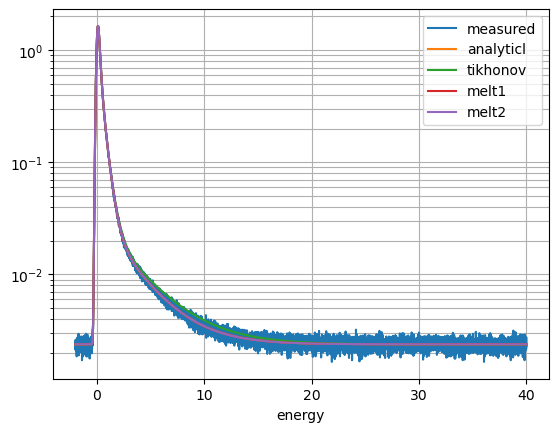

In [21]:
melt_result_model1 = LifetimeModel('', τ_grid, melt_q1/np.trapz(melt_q1,τ_grid))
melt_result_model2 = LifetimeModel('', τ_grid, melt_q2/np.trapz(melt_q2,τ_grid))

melt_lifetime1 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model1,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
melt_lifetime2 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model2,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
(tikhonov_lifetime.lifetime/random_spectrum.lifetime.integrate('energy')).plot(label='tikhonov')
melt_lifetime1.lifetime.plot(label='melt1')
melt_lifetime2.lifetime.plot(label='melt2')
plt.grid(which="both")


plt.legend()

In [22]:
(((random_spectrum.lifetime.counts - melt_lifetime2.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.9932578729252531

In [23]:
(((random_spectrum.lifetime.counts - melt_lifetime1.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.9932578674078489